In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from pathlib import Path
# Load the dataset
Project_Root = Path.cwd().parent

Data_Path = Project_Root / "Data"/"processed"/"Gurgaon_merged_cleaned_2.csv"
df = pd.read_csv(Data_Path)
df.sample(5)


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
2295,flat,ashiana anmol,sector 48,0.93,7294.0,1275.0,Super Built up area 1275(118.45 sq.m.)Built Up...,2,2,2,...,875.00,NaN,1000.0,0,0,0,0,1,2,31
843,flat,emaar palm gardens,sector 83,3.15,8400.0,3750.0,Super Built up area 3750(348.39 sq.m.)Built Up...,5,7,3+,...,2444.94,NaN,3200.0,0,1,0,0,0,0,165
3136,house,NaN,sector 7,0.90,10000.0,900.0,Plot area 100(83.61 sq.m.),6,4,3,...,NaN,100.0,NaN,0,1,0,0,1,0,44
2446,flat,sare green parc,sector 92,0.75,4820.0,1556.0,Built Up area: 1556 (144.56 sq.m.)Carpet area:...,3,2,2,...,1261.00,NaN,1556.0,0,0,0,0,0,2,0
3707,house,ansal sushant residency,sector 57,4.60,17037.0,2700.0,Plot area 300(250.84 sq.m.),6,6,3,...,NaN,300.0,NaN,1,1,1,1,0,1,102


In [7]:
# Fill missing values in 'built_up_area' with corresponding values from 'Plot_area'
df['built_up_area'] = df['built_up_area'].fillna(df['Plot_area'])

In [9]:
df.drop(columns = "Plot_area", inplace = True)

In [10]:
df.shape

(3961, 23)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3961 non-null   object 
 1   society              3391 non-null   object 
 2   sector               3961 non-null   object 
 3   price                3941 non-null   float64
 4   price_per_sqft       3941 non-null   float64
 5   area                 3941 non-null   float64
 6   areaWithType         3961 non-null   object 
 7   bedRoom              3961 non-null   int64  
 8   bathroom             3961 non-null   int64  
 9   balcony              3961 non-null   object 
 10  floorNum             2992 non-null   float64
 11  facing               2784 non-null   object 
 12  agePossession        3960 non-null   object 
 13  super_built_up_area  1934 non-null   float64
 14  carpet_area          2003 non-null   float64
 15  built_up_area        1859 non-null   f

In [15]:
df.duplicated().sum()

np.int64(129)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum() # Check of duplicates have been removed

np.int64(0)

## Univariate Analysis with Property type

<Axes: title={'center': 'Property Type Distribution'}, xlabel='property_type'>

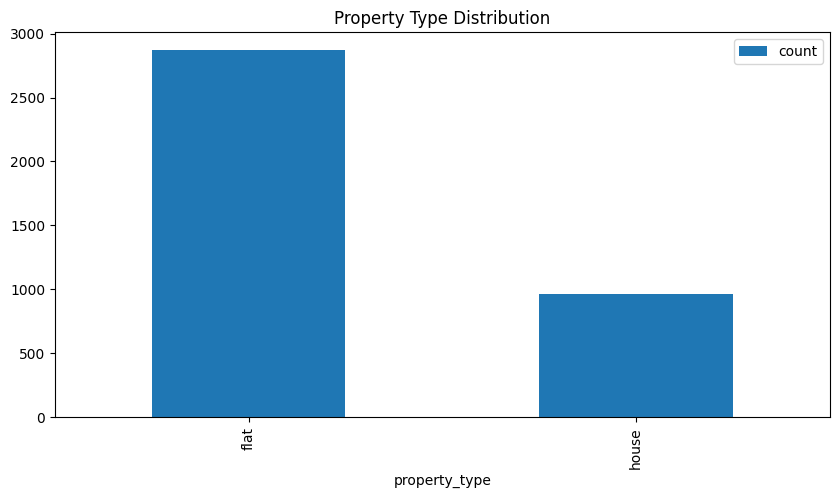

In [21]:
df.property_type.value_counts().plot(kind = 'bar', figsize = (10,5), title = "Property Type Distribution", legend = True, )

# Observation
The Data consists of 70 to 75 percent of the property type and remaining house.


# Society

In [23]:
df.sample(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,carpet_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
1210,flat,m3m woodshire,sector 107,0.9,6588.0,1366.0,Super Built up area 1366(126.91 sq.m.),2,2,3+,...,1366.0,NaN,NaN,0,0,0,0,0,2,21


In [25]:
df.society.value_counts().shape

(723,)

In [30]:
df.society.value_counts()

society
tulip violet                            75
ss the leaf                             73
shapoorji pallonji joyville gurugram    42
dlf new town heights                    42
signature global park                   35
                                        ..
imperia aashiyara                        1
g l s arawali homes                      1
adarsh nagar                             1
kamal residence                          1
maa bhagwati residency                   1
Name: count, Length: 723, dtype: int64

In [37]:
df[df['society'] != "independent"]['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.022992
ss the leaf                             0.045371
shapoorji pallonji joyville gurugram    0.058246
dlf new town heights                    0.071122
signature global park                   0.081852
                                          ...   
ramsons kshitij                         0.480074
dlf the primus                          0.484059
umang winter hills                      0.488044
ireo the corridors                      0.491723
central park flower valley              0.495402
Name: proportion, Length: 75, dtype: float64

In [47]:
society_counts = df.society.value_counts()

# Frequency distribution of the society column
frequency_bin = {
    'High(>50)'        : (society_counts>50).sum(),
    'Average(10 - 49)' : ((society_counts>10) & (society_counts<50)).sum(),
    'Low(2 - 9)'       : ((society_counts>2) & (society_counts<10)).sum(),
    'very Low (1)'     : (society_counts ==1).sum()
}
frequency_bin

{'High(>50)': np.int64(2),
 'Average(10 - 49)': np.int64(86),
 'Low(2 - 9)': np.int64(182),
 'very Low (1)': np.int64(342)}

<Axes: xlabel='society'>

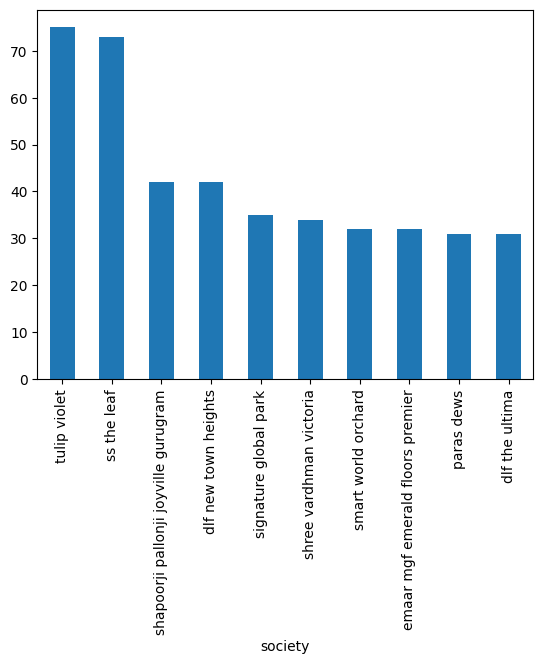

In [52]:
df.society.value_counts().head(10).plot(kind= 'bar')

In [55]:
df[df.society.isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,carpet_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
2758,flat,NaN,sector 78,0.60,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,NaN,1625.0,0,0,0,0,0,2,0
2998,house,NaN,sector 21a faridabad,5.70,105751.0,539.0,Plot area 539(50.07 sq.m.),5,4,2,...,NaN,NaN,539.0,0,1,1,1,0,0,49
2999,house,NaN,sector 43,2.10,38251.0,549.0,Plot area 61(51 sq.m.),10,10,3+,...,NaN,NaN,61.0,0,1,0,0,0,2,20
3000,house,NaN,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,...,NaN,NaN,129.0,0,1,0,0,0,1,49
3001,house,NaN,sector 43,3.00,53763.0,558.0,Plot area 62(51.84 sq.m.),12,12,3+,...,NaN,NaN,62.0,0,0,0,0,1,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3950,house,NaN,sector 46,5.65,23870.0,2367.0,Plot area 263(219.9 sq.m.),8,6,3+,...,NaN,NaN,263.0,0,1,0,0,0,0,67
3951,house,NaN,sector 46,3.55,24500.0,1449.0,Plot area 161(134.62 sq.m.),5,4,3+,...,NaN,NaN,161.0,0,1,0,0,0,0,73
3952,house,NaN,sector 46,3.60,24845.0,1449.0,Plot area 161(134.62 sq.m.),5,5,3+,...,NaN,NaN,161.0,0,1,0,0,0,0,75
3953,house,NaN,sector 55,3.10,20026.0,1548.0,Plot area 172(143.81 sq.m.),5,4,3+,...,NaN,NaN,172.0,0,1,0,1,0,0,59
